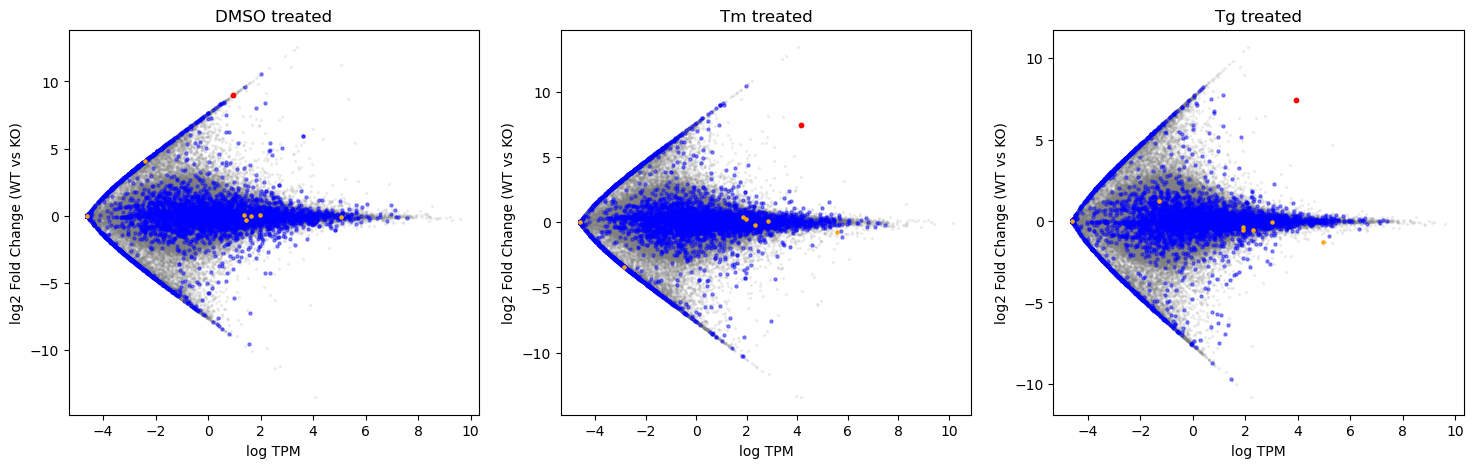

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

samples = ['WT_DMSO', 'KO_DMSO', 'WT_Tm', 'KO_Tm', 'WT_Tg', 'KO_Tg']

trans_tpm = pd.DataFrame()
for i, sample in enumerate(samples):
    miniquant_path = f'results/hela_tm_tg_mix/miniquant/{sample}/abundance.tsv'
    if i == 0:
        trans_tpm = pd.read_csv(
            miniquant_path, sep='\t', usecols=['Transcript_id', 'Effective_length', 'TPM'],
            index_col = 'Transcript_id'
        )[['Effective_length', 'TPM']]
        trans_tpm.rename(columns={'TPM': sample}, inplace=True)
    else:
        sample_tpm = pd.read_csv(
            miniquant_path, sep='\t', usecols=['Transcript_id', 'TPM'],
            index_col = 'Transcript_id'
        )
        trans_tpm[sample] = sample_tpm['TPM']

for i, experiment in enumerate(['DMSO', 'Tm', 'Tg']):
    trans_tpm[f'{experiment}_fold_change'] = (trans_tpm[f'WT_{experiment}'] + 0.01) / (trans_tpm[f'KO_{experiment}'] + 0.01)
    trans_tpm[f'{experiment}_log2FC'] = np.log2(trans_tpm[f'{experiment}_fold_change'])
    trans_tpm[f'{experiment}_mean_TPM'] = trans_tpm[[f'WT_{experiment}', f'KO_{experiment}']].mean(axis=1)
    trans_tpm[f'{experiment}_logTPM'] = trans_tpm[f'{experiment}_mean_TPM'].apply(lambda x: np.log(x + 0.01))

nc_transcripts_ids = []
nc_ids_cache = 'results/hela_tm_tg_mix/stringtie_viral/nc_transcripts_ids.txt'
with open(nc_ids_cache, 'r') as f:
    nc_transcripts_ids = [line.strip() for line in f]

plt.figure(figsize=(18, 5))
for i, experiment in enumerate(['DMSO', 'Tm', 'Tg']):
    # MA plot
    plot_df = trans_tpm[[f'{experiment}_logTPM', f'{experiment}_log2FC']].copy()
    plot_df.columns = ['logTPM', 'log2FC']
    # highlight some points
    nc_points = plot_df.loc[nc_transcripts_ids]
    xbp1_points = plot_df.loc[[
        'ENST00000216037.10', 'ENST00000403532.7', 'ENST00000933819.1', 'ENST00000484256.1',
        'ENST00000877101.1', 'ENST00000405219.7', 'ENST00000482720.1'
    ]]
    xbp1s_point = plot_df.loc['ENST00000344347.6']

    plt.subplot(1, 3, i + 1)
    plt.scatter(plot_df['logTPM'], plot_df['log2FC'], alpha=0.1, color='gray', s=2)
    plt.scatter(nc_points['logTPM'], nc_points['log2FC'], alpha=0.4, color='blue', s=5)
    plt.scatter(xbp1_points['logTPM'], xbp1_points['log2FC'], color='orange', s=5)
    plt.scatter(xbp1s_point['logTPM'], xbp1s_point['log2FC'], color='red', s=10)
    plt.xlabel('log TPM')
    plt.ylabel('log2 Fold Change (WT vs KO)')
    plt.title(f'{experiment} treated')

plt.show()



In [17]:
nc_tpm = trans_tpm.loc[nc_transcripts_ids]
nc_tpm = nc_tpm[(nc_tpm['Tg_log2FC'] > 1) & (nc_tpm['Tm_log2FC'] > 1)]
nc_tpm.sort_values(by='Tm_log2FC', ascending=False, inplace=True)
nc_tpm

,Effective_length,WT_DMSO,KO_DMSO,WT_Tm,KO_Tm,WT_Tg,KO_Tg,DMSO_fold_change,DMSO_log2FC,DMSO_mean_TPM,DMSO_logTPM,Tm_fold_change,Tm_log2FC,Tm_mean_TPM,Tm_logTPM,Tg_fold_change,Tg_log2FC,Tg_mean_TPM,Tg_logTPM
Transcript_id,,,,,,,,,,,,,,,,,,,
MSTRG.1012.1,1258.0,0.612222,0.240639,4.421110,0.000000,0.043942,0.001714,2.482543,1.311818,0.426431,-0.829126,443.111000,8.791524,2.210555,0.797757,4.605097,2.203231,0.022828,-3.416473
MSTRG.34350.1,347.0,0.778648,0.310782,1.945320,0.000000,3.376410,0.249705,2.458517,1.297788,0.544715,-0.589301,195.532000,7.611261,0.972660,-0.017492,13.039449,3.704811,1.813057,0.600515
ENST00000344347.6,1585.0,5.172090,0.000000,127.245000,0.702964,101.210000,0.583020,518.209000,9.017390,2.586045,0.953989,178.487273,7.479677,63.973982,4.158633,170.685643,7.415198,50.896510,3.929991
MSTRG.1448.1,3355.0,2.293140,2.553880,3.187790,0.011660,1.966170,0.890428,0.898303,-0.154727,2.423510,0.889335,147.633689,7.205878,1.599725,0.476063,2.194701,1.134024,1.428299,0.363461
MSTRG.1359.1,781.0,0.000395,0.000619,1.249780,0.000839,0.075623,0.001651,0.978846,-0.030846,0.000507,-4.555702,116.228787,6.860824,0.625309,-0.453643,7.349184,2.877584,0.038637,-3.023378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSTRG.25005.14,8988.0,1.441780,2.374800,4.871080,2.345030,2.027760,0.989231,0.608764,-0.716045,1.908290,0.651434,2.072619,1.051455,3.608055,1.285937,2.039328,1.028094,1.508495,0.417720
MSTRG.28638.8,3298.0,2.145580,2.057170,7.672910,3.770930,4.304190,2.122860,1.042769,0.060419,2.101375,0.747339,2.032016,1.022912,5.721920,1.746051,2.022725,1.016300,3.213525,1.170475
ENST00000442076.2,2264.0,0.034613,0.091759,0.035315,0.012407,0.101422,0.045559,0.438416,-1.189629,0.063186,-2.614749,2.022341,1.016026,0.023861,-3.385493,2.005482,1.003949,0.073490,-2.483024
